In [108]:
# ===============================================
# 1. Import Libraries
# ===============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.pipeline import Pipeline

import joblib
import pickle
import os

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [109]:
# ===============================================
# 2. Load Dataset
# ===============================================

df = pd.read_csv("../dataset/cleaned_dataset.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (21588, 27)


In [110]:
# ===============================================
# 3. Remove Redundant Features
# ===============================================

df = df.drop(columns=[
    "total_sqft",
    "yr_built",
    "yr_renovated",
    "sale_year"
])

In [111]:
# ===============================================
# 4. Encode Zipcode
# ===============================================

df["zipcode"] = df["zipcode"].astype(str)

df = pd.get_dummies(
    df,
    columns=["zipcode"],
    drop_first=True
)

In [112]:
# ===============================================
# 5. Define Features and Target
# ===============================================

X = df.drop(["price", "price_log"], axis=1)
y = df["price_log"]

print("Total Features:", X.shape[1])

Total Features: 89


In [113]:
# ===============================================
# 6. Train Test Split
# ===============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (17270, 89)
Test Shape: (4318, 89)


In [114]:
# ===============================================
# 7. Scaling (ONLY continuous features)
# ===============================================

continuous_cols = [
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_basement',
    'sqft_living15',
    'sqft_lot15',
    'lat',
    'long',
    'house_age'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [115]:
# ===============================================
# 8. Train Baseline Models
# ===============================================

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():

    if name == "Linear Regression":

        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        cv_score = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    else:

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        cv_score = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="r2"
        ).mean()

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2, cv_score])

results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2 Score","CV R2"]
)

print("\nBaseline Model Performance")
print(results_df.sort_values("RMSE"))


Baseline Model Performance
               Model       MAE      RMSE  R2 Score     CV R2
2      Random Forest  0.123007  0.173561  0.891230  0.884736
3  Gradient Boosting  0.134449  0.181747  0.880728  0.880855
0  Linear Regression  0.134516  0.184312  0.877337  0.878521
1      Decision Tree  0.176462  0.243613  0.785708  0.762707


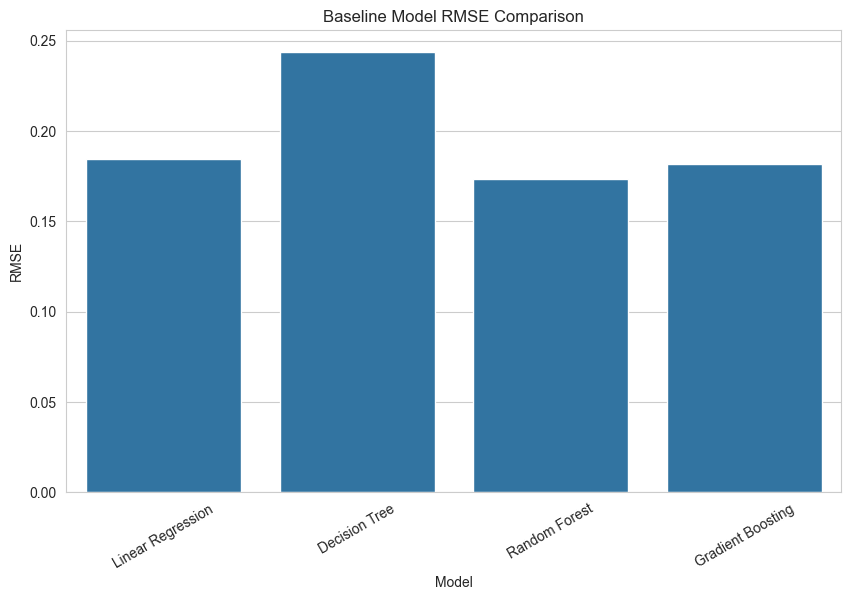

In [116]:
# ===============================================
# 9. Baseline Model Comparison
# ===============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Baseline Model RMSE Comparison")
plt.xticks(rotation=30)

plt.show()

In [117]:
# ===============================================
# 10. Select Top 2 Models
# ===============================================

top_models = (
    results_df
    .sort_values("RMSE")
    .head(2)["Model"]
    .values
)

print("Top Models:", top_models)

Top Models: ['Random Forest' 'Gradient Boosting']


In [118]:
# ===============================================
# 11. Hyperparameter Tuning
# ===============================================

best_models = {}

for model_name in top_models:
    print("\nTuning:", model_name)

    if model_name == "Random Forest":
        param_dist = {
            'n_estimators':[200,300,400,500],
            'max_depth':[10,20,30,None],
            'min_samples_split':[2,5,10],
            'min_samples_leaf':[1,2,4],
            'max_features':['sqrt','log2']
        }
        model = RandomForestRegressor(random_state=42)

    elif model_name == "Gradient Boosting":
        param_dist = {
            'n_estimators':[100,200,300],
            'learning_rate':[0.01,0.05,0.1],
            'max_depth':[3,4,5],
            'subsample':[0.8,1.0]
        }
        model = GradientBoostingRegressor(random_state=42)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=25,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    search.fit(X_train, y_train)

    best_models[model_name] = search.best_estimator_
    print("Best Parameters:", search.best_params_)


Tuning: Random Forest
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Tuning: Gradient Boosting
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}


In [119]:
# ===============================================
# 12. Compare Tuned Models
# ===============================================

final_results = []

for name, model in best_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    final_results.append([name, mae, rmse, r2])

final_df = pd.DataFrame(
    final_results,
    columns=["Model","MAE","RMSE","R2 Score"]
)

print("\nTuned Model Performance")
print(final_df.sort_values("RMSE"))


Tuned Model Performance
               Model       MAE      RMSE  R2 Score
1  Gradient Boosting  0.114485  0.159630  0.907990
0      Random Forest  0.126979  0.178402  0.885078


In [120]:
# ===============================================
# 13. Select Best Final Model
# ===============================================

best_model_name = final_df.sort_values("RMSE").iloc[0]["Model"]
final_model = best_models[best_model_name]
print("Final Selected Model:", best_model_name)
preds = final_model.predict(X_test)

Final Selected Model: Gradient Boosting


In [121]:
# ===============================================
# 14. Convert Predictions to Real Price
# ===============================================

actual_price = np.expm1(y_test)
pred_price = np.expm1(preds)
mae_price = mean_absolute_error(actual_price, pred_price)
rmse_price = np.sqrt(mean_squared_error(actual_price, pred_price))
r2_price = r2_score(actual_price, pred_price)

print("\nPerformance on Actual Price")
print("MAE:", mae_price)
print("RMSE:", rmse_price)
print("R2:", r2_price)


Performance on Actual Price
MAE: 61613.97067594005
RMSE: 105889.16501172958
R2: 0.910303493862441


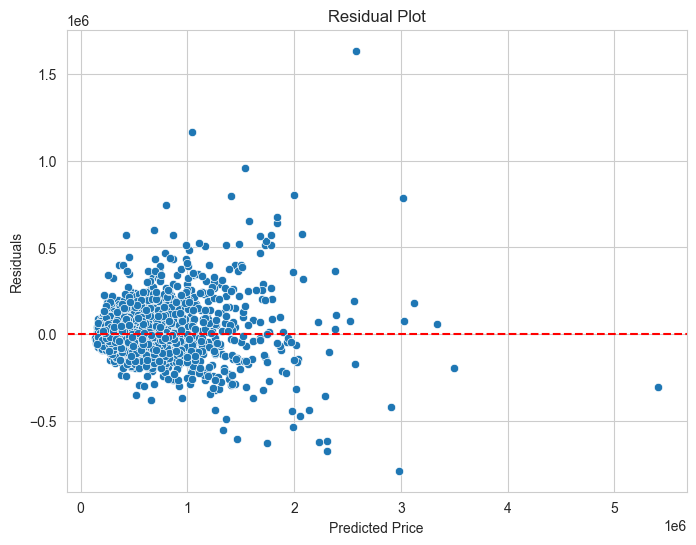

In [122]:
# ===============================================
# 15. Residual Plot
# ===============================================

residuals = actual_price - pred_price

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pred_price,
    y=residuals
)
plt.axhline(0,color="red",linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

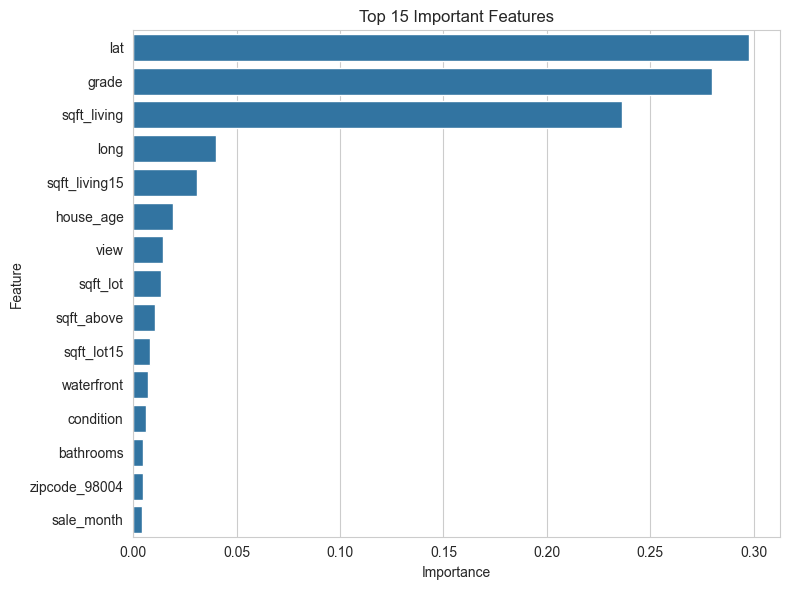

In [123]:
# ===============================================
# 16. Feature Importance
# ===============================================

if hasattr(final_model,"feature_importances_"):
    importances = final_model.feature_importances_

    feat_imp = pd.DataFrame({
        "Feature":X.columns,
        "Importance":importances
    }).sort_values("Importance",ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(
        data=feat_imp.head(15),
        x="Importance",
        y="Feature"
    )
    plt.title("Top 15 Important Features")
    plt.tight_layout()
    plt.show()

In [124]:
# ===============================================
# 17. Save Final Pipeline
# ===============================================

pipeline = Pipeline([("model",final_model)])
pipeline.fit(X_train,y_train)

os.makedirs("../models",exist_ok=True)

joblib.dump(pipeline, "../models/final_house_price_model.pkl")

with open("../models/columns.pkl","wb") as f:
    pickle.dump(X.columns.tolist(), f)
print("\nPipeline and columns saved successfully!")


Pipeline and columns saved successfully!
